# 🚀 머신러닝 실습 : 고객 구매 데이터로 성별 예측 모델링 (분류 문제)

* 주어진 데이터는 백화점 고객의 1년 간 구매 데이터입니다.
* 고객 3,500명에 대한 학습용 데이터(y.csv, X.csv)를 이용하여 성별예측 모형을 만들어보세요.
* 모델의 성능은 자유롭게 측정해봅니다!

[실습 프로세스]
1. 데이터 불러오기  
2. 데이터 탐색
3. 데이터 전처리  
4. 학습/테스트 데이터 분리  
5. 모델 선택 및 학습  
6. 예측 및 평가  

위의 프로세스에 따라 한단계씩 과정을 진행하겠습니다.
LogisticRegression 으로  기준 예측 성능을 확인하고, 
평가지표는 정확도, 정밀도, 재현율, f1, confusion_matrix를 사용합니다.
이후 DecisionTree, RandomForest, XGBoost로 모델 성능을 비교하겠습니다.

주의사항: 
코드 작성시 지나치게 복잡하지 않고 최대한 심플(예를 들어 람다나 3항연산을 배제)한 코드를 선호합니다.
구조 변경이나, 복잡한 제어문, 함수 정의, ml 모델의 함수호출등에는 주석을 추가하세요.
각 단계마다 실행결과를 분석해서 노트북셀로 정리하려고 합니다.
- 주석은 이해하기 쉬운 표현을 사용하고,
- 결과 분석 문장은 마크다운 형식으로 작성하세요(h2, h3는 사용금지)
- 모델링 코드는 ipynb 형식입니다.

# 0. 라이브러리 불러오기
라이브러리를 가져와서 과정을 준비합니다

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore')

# 1. 데이터 불러오기
데이터를 가져와서 과정을 준비합시다.
인코딩 방식은 'euc-kr' 을 활용하세요.

데이터 출처 : 한국데이터산업진흥원 빅데이터분석기사 실기 공개 예시 문항

독립 변수 데이터셋 : ./data/X.csv

종속 변수 데이터셋 : ./data/y.csv

데이터 파일을 불러옵니다. 보통 CSV 파일을 pandas로 읽어옵니다.

In [2]:
X = pd.read_csv(r'C:\Users\Admin\hipython\data\X.csv', encoding='euc-kr')
y = pd.read_csv(r'C:\Users\Admin\hipython\data\y.csv', encoding='euc-kr')

print(X.shape, y.shape)

(3500, 10) (3500, 2)


In [3]:
# import os
# # 노트북 파일이 있는 폴더로 이동 (예시)
# os.chdir(r'C:\githome\hipython_rep')

# # 변경 후 확인
# print("변경 후:", os.getcwd())

In [4]:
X.head()

,cust_id,총구매액,최대구매액,환불금액,주구매상품,주구매지점,내점일수,내점당구매건수,주말방문비율,구매주기
0,0,68282840,11264000,6860000.0,기타,강남점,19,3.894737,0.527027,17
1,1,2136000,2136000,300000.0,스포츠,잠실점,2,1.500000,0.000000,1
2,2,3197000,1639000,NaN,남성 캐주얼,관악점,2,2.000000,0.000000,1
3,3,16077620,4935000,NaN,기타,광주점,18,2.444444,0.318182,16
4,4,29050000,24000000,NaN,보석,본 점,2,1.500000,0.000000,85


In [5]:
y.head()

,cust_id,gender
0,0,0
1,1,0
2,2,1
3,3,1
4,4,0


# 2. 데이터 탐색하기
데이터를 이해할 수 있도록 탐색과정을 수행해봅시다.
데이터의 상위 몇 개 행을 출력하여 전체 구조를 미리 확인합니다.

데이터의 요약 정보나 통계 정보를 출력해 변수들의 유형과 분포를 확인합니다.

데이터의 요약 정보나 통계 정보를 출력해 변수들의 유형과 분포를 확인합니다.

In [6]:
# 데이터 기본 정보 확인
print('=== X 데이터 정보 ===')
print(X.info())
print()
print('=== y 데이터 정보 ===')
print(y.info())

=== X 데이터 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cust_id  3500 non-null   int64  
 1   총구매액     3500 non-null   int64  
 2   최대구매액    3500 non-null   int64  
 3   환불금액     1205 non-null   float64
 4   주구매상품    3500 non-null   str    
 5   주구매지점    3500 non-null   str    
 6   내점일수     3500 non-null   int64  
 7   내점당구매건수  3500 non-null   float64
 8   주말방문비율   3500 non-null   float64
 9   구매주기     3500 non-null   int64  
dtypes: float64(3), int64(5), str(2)
memory usage: 273.6 KB
None

=== y 데이터 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   cust_id  3500 non-null   int64
 1   gender   3500 non-null   int64
dtypes: int64(2)
memory usage: 54.8 KB
None


In [7]:
# 기술 통계 정보 확인
print('=== X 기술통계 ===')
display(X.describe())
print()
print('=== y 타겟 분포 ===')
print(y['gender'].value_counts())
print('0: 남성, 1: 여성')

=== X 기술통계 ===


,cust_id,총구매액,최대구매액,환불금액,내점일수,내점당구매건수,주말방문비율,구매주기
count,3500.000000,3.500000e+03,3.500000e+03,1.205000e+03,3500.000000,3500.000000,3500.000000,3500.000000
mean,1749.500000,9.191925e+07,1.966424e+07,2.407822e+07,19.253714,2.834963,0.307246,20.958286
std,1010.507298,1.635065e+08,3.199235e+07,4.746453e+07,27.174942,1.912368,0.289752,24.748682
min,0.000000,-5.242152e+07,-2.992000e+06,5.600000e+03,1.000000,1.000000,0.000000,0.000000
25%,874.750000,4.747050e+06,2.875000e+06,2.259000e+06,2.000000,1.666667,0.027291,4.000000
50%,1749.500000,2.822270e+07,9.837000e+06,7.392000e+06,8.000000,2.333333,0.256410,13.000000
75%,2624.250000,1.065079e+08,2.296250e+07,2.412000e+07,25.000000,3.375000,0.448980,28.000000
max,3499.000000,2.323180e+09,7.066290e+08,5.637530e+08,285.000000,22.083333,1.000000,166.000000



=== y 타겟 분포 ===
gender
0    2184
1    1316
Name: count, dtype: int64
0: 남성, 1: 여성


# 3. 데이터 전처리
전처리 과정을 통해서 머신러닝에 사용할 수 있는 형태의 데이터 준비
필요한 라이브러리를 불러옵니다.

인코딩 : LabelEncoder
데이터 표준화 : StandardScaler
단순히 1부터의 숫자를 부여한 'cust_id'를 수치형 변수로 받아들이면, 결과가 왜곡될 수 있으니 컬럼을 제거합니다.
데이터에 결측치가 있는지 확인해보세요
결측치에 0으로 채워 넣어 모델 학습에 지장이 없도록 합니다.
문자형 범주 데이터를 숫자로 바꾸기 위한 인코딩을 수행합니다.

각 데이터에 표준화를 적용하여 데이터의 스케일(크기 차이)을 맞춰줍니다.

평균을 0, 표준편차를 1로 맞춰서 → 데이터가 정규 분포 형태로 변환되도록 하세요

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [9]:
# cust_id 컬럼 제거 (의미 없는 식별자)
X = X.drop(columns=['cust_id'])
y = y.drop(columns=['cust_id'])

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (3500, 9)
y shape: (3500, 1)


In [10]:
# 결측치 확인
print('=== X 결측치 현황 ===')
print(X.isnull().sum())

=== X 결측치 현황 ===
총구매액          0
최대구매액         0
환불금액       2295
주구매상품         0
주구매지점         0
내점일수          0
내점당구매건수       0
주말방문비율        0
구매주기          0
dtype: int64


In [11]:
# 결측치 0으로 채우기
X = X.fillna(0)

# 결측치 처리 확인
print('처리 후 결측치:')
print(X.isnull().sum())

처리 후 결측치:
총구매액       0
최대구매액      0
환불금액       0
주구매상품      0
주구매지점      0
내점일수       0
내점당구매건수    0
주말방문비율     0
구매주기       0
dtype: int64


In [12]:
# 문자형 범주형 컬럼 Label Encoding
le = LabelEncoder()

cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
print('인코딩 대상 컬럼:', cat_cols)

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

print('인코딩 완료')
X.head()

인코딩 대상 컬럼: ['주구매상품', '주구매지점']
인코딩 완료


,총구매액,최대구매액,환불금액,주구매상품,주구매지점,내점일수,내점당구매건수,주말방문비율,구매주기
0,68282840,11264000,6860000.0,5,0,19,3.894737,0.527027,17
1,2136000,2136000,300000.0,21,19,2,1.500000,0.000000,1
2,3197000,1639000,0.0,6,1,2,2.000000,0.000000,1
3,16077620,4935000,0.0,5,2,18,2.444444,0.318182,16
4,29050000,24000000,0.0,15,8,2,1.500000,0.000000,85


In [13]:
# 학습 / 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler 표준화 (평균 0, 표준편차 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # 훈련 데이터로 fit 후 transform
X_test  = scaler.transform(X_test)        # 테스트 데이터는 transform만

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test  shape:', y_test.shape)

X_train shape: (2800, 9)
X_test  shape: (700, 9)
y_train shape: (2800, 1)
y_test  shape: (700, 1)


In [14]:
# 공통 평가 함수 정의
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

def get_clf_eval(model_name, y_test, pred):
    cm        = confusion_matrix(y_test, pred)
    accuracy  = accuracy_score (y_test, pred)
    precision = precision_score(y_test, pred)
    recall    = recall_score   (y_test, pred)
    f1        = f1_score       (y_test, pred)
    print(f'[ {model_name} ]')
    print('Confusion Matrix:')
    print(cm)
    print(f'  정확도(Accuracy) : {accuracy:.4f}')
    print(f'  정밀도(Precision): {precision:.4f}')
    print(f'  재현율(Recall)   : {recall:.4f}')
    print(f'  F1 Score         : {f1:.4f}')
    print('-' * 40)
    return {'model': model_name, 'accuracy': accuracy,
            'precision': precision, 'recall': recall, 'f1': f1}

# 5-1. 모델링 - LogisticRegression
본격적으로 모델을 선언하고 학습시킵니다.
필요한 라이브러리를 불러옵니다.

모델을 선언하여 객체화시킵니다.

모델을 학습 데이터에 맞춰 학습시킵니다.

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
lr_clf = LogisticRegression(max_iter=2000, random_state=42)

In [17]:
lr_clf.fit(X_train, y_train.values.ravel())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

# 6-1. 예측 성능 확인해보기 - LogisticRegression
학습된 모델로 테스트 데이터에 대한 예측을 수행합니다.
학습시킨 모델의 성능을 알아봅니다
각 평가지표로 모델의 성능을 수치화하여 확인합니다.
필요한 라이브러리를 import 하고 성능을 확인해보세요 (정확도, 정밀도, 재현율, f1, confusion_matrix)

In [18]:
lr_pred = lr_clf.predict(X_test)
results = []
results.append(get_clf_eval('LogisticRegression', y_test, lr_pred))

[ LogisticRegression ]
Confusion Matrix:
[[407  30]
 [227  36]]
  정확도(Accuracy) : 0.6329
  정밀도(Precision): 0.5455
  재현율(Recall)   : 0.1369
  F1 Score         : 0.2188
----------------------------------------


# 5-2. 모델링 - DecisionTreeClassifier
본격적으로 모델을 선언하고 학습시킵니다.
필요한 라이브러리를 불러옵니다.

모델을 선언하여 객체화시킵니다.

모델을 학습 데이터에 맞춰 학습시킵니다.

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
dt_clf = DecisionTreeClassifier(random_state=42)

In [21]:
dt_clf.fit(X_train, y_train.values.ravel())

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

# 6-2. 예측 성능 확인해보기 - DecisionTreeClassifier
학습된 모델로 테스트 데이터에 대한 예측을 수행합니다.
학습시킨 모델의 성능을 알아봅니다
각 평가지표로 모델의 성능을 수치화하여 확인합니다.
필요한 라이브러리를 import 하고 성능을 확인해보세요 (정확도, 정밀도, 재현율, f1, confusion_matrix)

In [22]:
dt_pred = dt_clf.predict(X_test)
results.append(get_clf_eval('DecisionTreeClassifier', y_test, dt_pred))

[ DecisionTreeClassifier ]
Confusion Matrix:
[[283 154]
 [151 112]]
  정확도(Accuracy) : 0.5643
  정밀도(Precision): 0.4211
  재현율(Recall)   : 0.4259
  F1 Score         : 0.4234
----------------------------------------


# 5-3. 모델링 - RandomForestClassifier
본격적으로 모델을 선언하고 학습시킵니다.
필요한 라이브러리를 불러옵니다.

모델을 선언하여 객체화시킵니다.

모델을 학습 데이터에 맞춰 학습시킵니다.

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

In [25]:
rf_clf.fit(X_train, y_train.values.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# 6-3. 예측 성능 확인해보기 - RandomForestClassifier
학습된 모델로 테스트 데이터에 대한 예측을 수행합니다.
학습시킨 모델의 성능을 알아봅니다
각 평가지표로 모델의 성능을 수치화하여 확인합니다.
필요한 라이브러리를 import 하고 성능을 확인해보세요 (정확도, 정밀도, 재현율, f1, confusion_matrix)

In [26]:
rf_pred = rf_clf.predict(X_test)
results.append(get_clf_eval('RandomForestClassifier', y_test, rf_pred))

[ RandomForestClassifier ]
Confusion Matrix:
[[353  84]
 [175  88]]
  정확도(Accuracy) : 0.6300
  정밀도(Precision): 0.5116
  재현율(Recall)   : 0.3346
  F1 Score         : 0.4046
----------------------------------------


# 5-4. 모델링 - XGBoost
본격적으로 모델을 선언하고 학습시킵니다.
필요한 라이브러리를 불러옵니다.

모델을 선언하여 객체화시킵니다.

모델을 학습 데이터에 맞춰 학습시킵니다.

In [27]:
from xgboost import XGBClassifier

In [28]:
xgb_clf = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')

In [29]:
xgb_clf.fit(X_train, y_train.values.ravel())

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

# 6-4. 예측 성능 확인해보기 - XGBoost
학습된 모델로 테스트 데이터에 대한 예측을 수행합니다.
학습시킨 모델의 성능을 알아봅니다
각 평가지표로 모델의 성능을 수치화하여 확인합니다.
필요한 라이브러리를 import 하고 성능을 확인해보세요 (정확도, 정밀도, 재현율, f1, confusion_matrix)

In [30]:
xgb_pred = xgb_clf.predict(X_test)
results.append(get_clf_eval('XGBoost', y_test, xgb_pred))

[ XGBoost ]
Confusion Matrix:
[[333 104]
 [150 113]]
  정확도(Accuracy) : 0.6371
  정밀도(Precision): 0.5207
  재현율(Recall)   : 0.4297
  F1 Score         : 0.4708
----------------------------------------


# 7. 위 4가지 모델의 학습 & 예측 & 평가 결과를 확인하고 최고 성능을 내는 모델을 찾아봅시다!
어떤 모델이 가장 성능이 좋은가요 ?

In [31]:
# 4가지 모델 성능 비교 요약
results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')
results_df = results_df.sort_values('f1', ascending=False)

print('=== 모델 성능 비교 (F1 기준 내림차순) ===')
display(results_df.style.highlight_max(axis=0, color='lightgreen'))

best_model = results_df.index[0]
print(f'\n🏆 최고 성능 모델: {best_model} (F1: {results_df.loc[best_model, "f1"]:.4f})')

=== 모델 성능 비교 (F1 기준 내림차순) ===


,accuracy,precision,recall,f1
model,,,,
XGBoost,0.637143,0.520737,0.429658,0.470833
DecisionTreeClassifier,0.564286,0.421053,0.425856,0.423440
RandomForestClassifier,0.630000,0.511628,0.334601,0.404598
LogisticRegression,0.632857,0.545455,0.136882,0.218845



🏆 최고 성능 모델: XGBoost (F1: 0.4708)


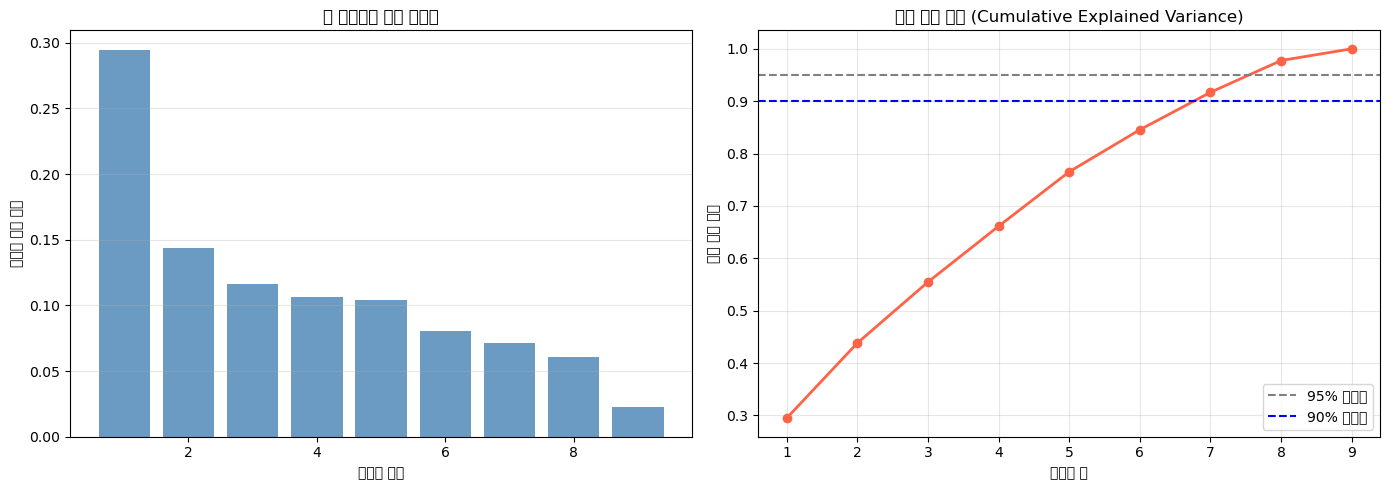

누적 분산 90% 달성에 필요한 주성분 수: 7개
누적 분산 95% 달성에 필요한 주성분 수: 8개
누적 분산 99% 달성에 필요한 주성분 수: 9개


In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 전체 주성분으로 PCA 수행 (분산 비율 확인용)
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

# 누적 분산 비율 계산
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 개별 주성분 기여율
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.8)
axes[0].set_xlabel('주성분 번호')
axes[0].set_ylabel('설명된 분산 비율')
axes[0].set_title('각 주성분의 분산 기여율')
axes[0].grid(axis='y', alpha=0.3)

# (2) 누적 분산 비율
axes[1].plot(range(1, len(cumvar)+1), cumvar, marker='o', color='tomato', linewidth=2)
axes[1].axhline(y=0.95, color='gray',  linestyle='--', label='95% 기준선')
axes[1].axhline(y=0.90, color='blue',  linestyle='--', label='90% 기준선')
axes[1].set_xlabel('주성분 수')
axes[1].set_ylabel('누적 분산 비율')
axes[1].set_title('누적 분산 비율 (Cumulative Explained Variance)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 90%, 95%, 99% 달성 시 필요한 주성분 수 출력
for threshold in [0.90, 0.95, 0.99]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f'누적 분산 {threshold*100:.0f}% 달성에 필요한 주성분 수: {n}개')

In [33]:
# 95% 분산 보존 기준으로 PCA 적용
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train)   # 훈련 데이터로 fit 후 transform
X_test_pca  = pca.transform(X_test)        # 테스트 데이터는 transform만

print(f'원본 특성 수     : {X_train.shape[1]}개')
print(f'PCA 후 특성 수   : {X_train_pca.shape[1]}개')
print(f'보존된 분산 비율 : {sum(pca.explained_variance_ratio_):.4f}')
print(f'X_train_pca shape : {X_train_pca.shape}')
print(f'X_test_pca  shape : {X_test_pca.shape}')

원본 특성 수     : 9개
PCA 후 특성 수   : 8개
보존된 분산 비율 : 0.9776
X_train_pca shape : (2800, 8)
X_test_pca  shape : (700, 8)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pca_results = []   # PCA 적용 모델 결과 저장용

models_pca = {
    'LR (PCA)'       : LogisticRegression(max_iter=2000, random_state=42),
    'DT (PCA)'       : DecisionTreeClassifier(random_state=42),
    'RF (PCA)'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost (PCA)'  : XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

for name, model in models_pca.items():
    model.fit(X_train_pca, y_train.values.ravel())
    pred = model.predict(X_test_pca)
    pca_results.append(get_clf_eval(name, y_test, pred))

[ LR (PCA) ]
Confusion Matrix:
[[407  30]
 [227  36]]
  정확도(Accuracy) : 0.6329
  정밀도(Precision): 0.5455
  재현율(Recall)   : 0.1369
  F1 Score         : 0.2188
----------------------------------------
[ DT (PCA) ]
Confusion Matrix:
[[275 162]
 [139 124]]
  정확도(Accuracy) : 0.5700
  정밀도(Precision): 0.4336
  재현율(Recall)   : 0.4715
  F1 Score         : 0.4517
----------------------------------------
[ RF (PCA) ]
Confusion Matrix:
[[349  88]
 [190  73]]
  정확도(Accuracy) : 0.6029
  정밀도(Precision): 0.4534
  재현율(Recall)   : 0.2776
  F1 Score         : 0.3443
----------------------------------------
[ XGBoost (PCA) ]
Confusion Matrix:
[[312 125]
 [174  89]]
  정확도(Accuracy) : 0.5729
  정밀도(Precision): 0.4159
  재현율(Recall)   : 0.3384
  F1 Score         : 0.3732
----------------------------------------


In [35]:
# 원본 모델 결과 DataFrame
df_orig = pd.DataFrame(results).set_index('model')
df_orig['데이터'] = '원본'

# PCA 모델 결과 DataFrame
df_pca = pd.DataFrame(pca_results).set_index('model')
df_pca['데이터'] = 'PCA'

# 통합 비교 DataFrame (F1 기준 내림차순)
df_all = pd.concat([df_orig, df_pca]).sort_values('f1', ascending=False)
df_all = df_all[['데이터', 'accuracy', 'precision', 'recall', 'f1']]
df_all.columns = ['데이터', '정확도', '정밀도', '재현율', 'F1 Score']

print('=== 전체 모델 성능 비교 (F1 기준 내림차순) ===')
display(
    df_all.style
    .highlight_max(subset=['정확도','정밀도','재현율','F1 Score'], axis=0, color='lightgreen')
    .format({'정확도':'{:.4f}', '정밀도':'{:.4f}', '재현율':'{:.4f}', 'F1 Score':'{:.4f}'})
)

best = df_all['F1 Score'].idxmax()
print(f'\n🏆 최고 성능 모델: {best}  (F1: {df_all.loc[best, "F1 Score"]:.4f})')

=== 전체 모델 성능 비교 (F1 기준 내림차순) ===


,데이터,정확도,정밀도,재현율,F1 Score
model,,,,,
XGBoost,원본,0.6371,0.5207,0.4297,0.4708
DT (PCA),PCA,0.5700,0.4336,0.4715,0.4517
DecisionTreeClassifier,원본,0.5643,0.4211,0.4259,0.4234
RandomForestClassifier,원본,0.6300,0.5116,0.3346,0.4046
XGBoost (PCA),PCA,0.5729,0.4159,0.3384,0.3732
RF (PCA),PCA,0.6029,0.4534,0.2776,0.3443
LogisticRegression,원본,0.6329,0.5455,0.1369,0.2188
LR (PCA),PCA,0.6329,0.5455,0.1369,0.2188



🏆 최고 성능 모델: XGBoost  (F1: 0.4708)


In [38]:
name_map = {
    'LogisticRegression'     : 'LR (PCA)',
    'DecisionTreeClassifier' : 'DT (PCA)',
    'RandomForestClassifier' : 'RF (PCA)',
    'XGBoost'                : 'XGBoost (PCA)'
}

rows = []
for orig_name, pca_name in name_map.items():
    f1_before = df_orig.loc[orig_name, 'f1']
    f1_after  = df_pca.loc[pca_name,  'f1']
    diff      = f1_after - f1_before
    rows.append({
        '모델'      : orig_name.replace('Classifier', '').strip(),
        '원본 F1'   : f1_before,
        'PCA F1'    : f1_after,
        'F1 변화량' : diff,
        '개선 여부' : '✅ 개선' if diff > 0 else ('➡ 동일' if diff == 0 else '❌ 하락')
    })

df_diff = pd.DataFrame(rows).set_index('모델')

print('=== 원본 vs PCA F1 Score 변화 비교 ===')
display(
    df_diff.style
    .format({'원본 F1':'{:.4f}', 'PCA F1':'{:.4f}', 'F1 변화량':'{:+.4f}'})
    .map(lambda v: 'color: green' if '개선' in str(v)   # applymap → map 으로 수정
         else ('color: red' if '하락' in str(v) else ''), subset=['개선 여부'])
)

=== 원본 vs PCA F1 Score 변화 비교 ===


,원본 F1,PCA F1,F1 변화량,개선 여부
모델,,,,
LogisticRegression,0.2188,0.2188,+0.0000,➡ 동일
DecisionTree,0.4234,0.4517,+0.0283,✅ 개선
RandomForest,0.4046,0.3443,-0.0603,❌ 하락
XGBoost,0.4708,0.3732,-0.0977,❌ 하락


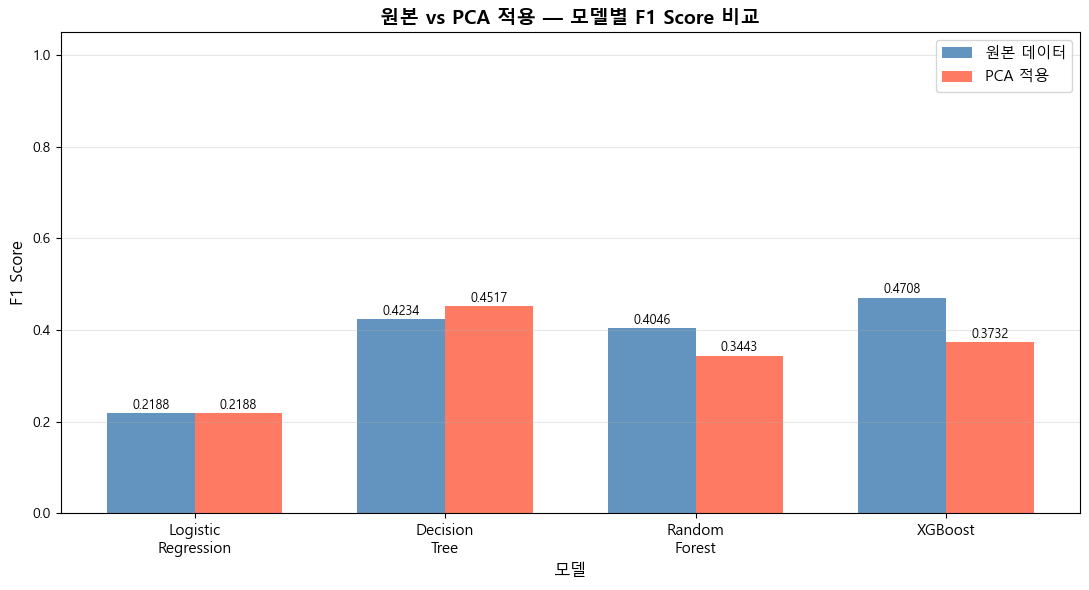

In [37]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'   # Windows
# matplotlib.rcParams['font.family'] = 'AppleGothic'  # Mac
matplotlib.rcParams['axes.unicode_minus'] = False

labels  = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'XGBoost']
f1_orig_vals = [df_orig.loc[m, 'f1'] for m in
                ['LogisticRegression','DecisionTreeClassifier','RandomForestClassifier','XGBoost']]
f1_pca_vals  = [df_pca.loc[m,  'f1'] for m in
                ['LR (PCA)','DT (PCA)','RF (PCA)','XGBoost (PCA)']]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, f1_orig_vals, width, label='원본 데이터', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_pca_vals,  width, label='PCA 적용',    color='tomato',    alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('모델', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('원본 vs PCA 적용 — 모델별 F1 Score 비교', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()